# Machine Learning — Scoring du risque de mortalité (BAAC 2024)

## Objectif
Estimer la probabilité qu’un accident soit mortel (is_fatal) à partir de variables disponibles avant l’issue de l’accident (temporalité, environnement, infrastructure routière).

L’objectif n’est pas de “prédire un décès” avec certitude, mais de produire un score de risque permettant de prioriser des situations à forte criticité.

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]

os.chdir(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

print("Nouveau CWD =", Path().resolve())
print("metrics.json existe ?", Path("reports/ml/metrics.json").exists())


Nouveau CWD = C:\Users\Hannae\Documents\Projets\accidents-france-baac
metrics.json existe ? True


In [2]:
import sys
print("Python used by Jupyter:", sys.executable)
print("sys.path[0]:", sys.path[0])


Python used by Jupyter: c:\Users\Hannae\Documents\Projets\accidents-france-baac\.venv\Scripts\python.exe
sys.path[0]: C:\Users\Hannae\AppData\Local\Programs\Python\Python311\python311.zip


In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

from src.ml.make_dataset import make_xy

## Données et construction de la cible

- **Grain d’analyse** : 1 ligne = 1 accident (`Num_Acc`)  
- **Cible** : `is_fatal = 1` si l’accident comporte au moins un usager “Tué”, sinon `0`.

La cible est construite à partir du fichier usagers (`grav_label`) puis **agrégée au niveau accident**. Les variables de gravité sont utilisées **uniquement pour créer la cible** et sont **exclues des features** afin d’éviter toute fuite d’information.

In [4]:
X, y = make_xy()
print("X shape:", X.shape)
print("Prevalence is_fatal:", y.mean())

display(X.head(3))
display(pd.DataFrame({
    "missing_rate": X.isna().mean()
}).sort_values("missing_rate", ascending=False).head(10))

X shape: (70248, 22)
Prevalence is_fatal: 0.053140302926773714


,jour,mois,weekday,hour,hrmn,lum,atm,surf,plan,infra,...,int,catr,circ,nbv,vosp,prof,lartpc,larrout,vma,dep
0,25,3,Monday,7,07:40,2,5,1,2,0,...,1,3,2,2,0,1,NaN,7,90,70
1,20,3,Wednesday,15,15:05,1,7,9,1,0,...,3,4,2,2,0,1,NaN,-1,30,21
2,20,3,Wednesday,15,15:05,1,7,9,1,0,...,3,4,1,1,0,1,NaN,-1,30,21


,missing_rate
lartpc,0.99953
jour,0.00000
mois,0.00000
vma,0.00000
larrout,0.00000
prof,0.00000
vosp,0.00000
nbv,0.00000
circ,0.00000
catr,0.00000


## Stratégie de split

Les accidents mortels étant rares, le split est réalisé en **stratifié** afin de conserver une proportion de cas mortels comparable entre apprentissage et test.  

À terme, lorsque plusieurs années seront intégrées, le split deviendra **temporel** (train sur années passées, test sur année récente) pour évaluer la robustesse du modèle dans le temps.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train prevalence:", float(y_train.mean()))
print("Test prevalence :", float(y_test.mean()))

Train size: (56198, 22)  Test size: (14050, 22)
Train prevalence: 0.05313356347200968
Test prevalence : 0.05316725978647687


## Modélisation : pipeline reproductible

Le modèle est entraîné via un **pipeline scikit-learn** afin de garantir une exécution reproductible :

- Imputation des valeurs manquantes
- Encodage des variables catégorielles (One-Hot Encoding)
- Modèles comparés :
  - **Régression logistique** (baseline interprétable)
  - **Gradient Boosting** (modèle non linéaire plus performant)

Le déséquilibre de classes (accidents mortels = classe rare) est géré via une **pondération des observations**.

In [6]:
metrics_path = Path("reports/ml/metrics.json")
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
best_model = metrics.get("best_model", "hgb")
print("Best model:", best_model)
print(pd.DataFrame(metrics).T)

model = load(Path("models") / f"{best_model}.joblib")
proba = model.predict_proba(X_test)[:, 1]

Best model: hgb
              pr_auc   roc_auc val_prevalence  n_train    n_val
logreg      0.144892  0.763928       0.053167  56198.0  14050.0
hgb         0.166494    0.7947       0.053167  56198.0  14050.0
best_model       hgb       hgb            hgb      hgb      hgb


## Pourquoi PR-AUC (et pas l’accuracy)

Le problème est fortement déséquilibré : une métrique comme l’accuracy peut être élevée même avec un modèle inutile (ex : prédire “non mortel” tout le temps).

La **PR-AUC (Precision-Recall AUC)** est privilégiée car elle mesure la capacité du modèle à **retrouver les cas rares** tout en limitant les fausses alertes.

### Calibration : un score exploitable

Le modèle produit une probabilité. La calibration permet de vérifier que les probabilités prédites correspondent aux fréquences réellement observées, condition essentielle pour un **score de risque opérationnel**.

In [7]:
pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)
brier = brier_score_loss(y_test, proba)

print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Brier:  {brier:.4f}")

PR-AUC: 0.1665
ROC-AUC: 0.7947
Brier:  0.1690


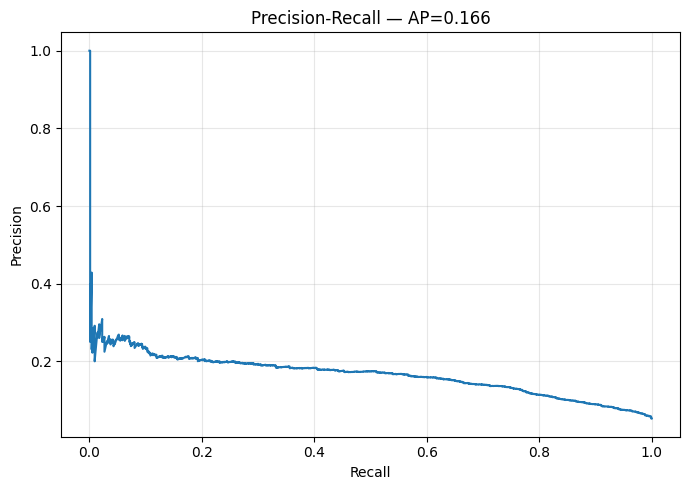

In [8]:
prec, rec, _ = precision_recall_curve(y_test, proba)
plt.figure(figsize=(7,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall — AP={pr_auc:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

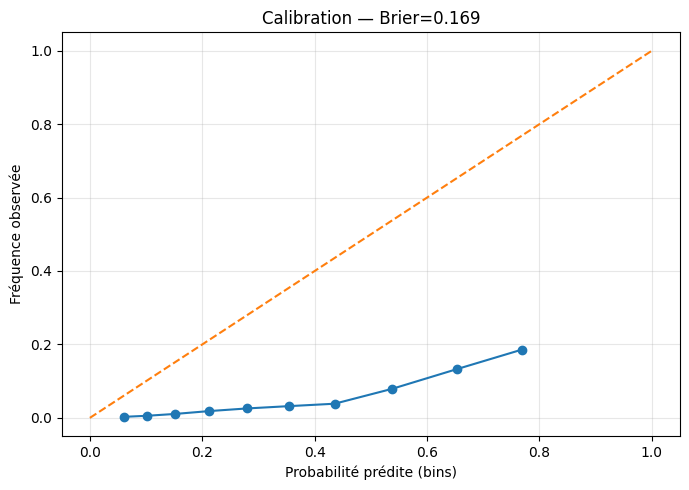

In [9]:
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
plt.figure(figsize=(7,5))
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Probabilité prédite (bins)")
plt.ylabel("Fréquence observée")
plt.title(f"Calibration — Brier={brier:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Seuil opérationnel : top 5% des accidents les plus risqués

Plutôt qu’un seuil arbitraire (0.5), on adopte une approche pragmatique : ne retenir que les **5% des accidents présentant le score de risque le plus élevé**.

Cette logique correspond à un contexte réel où les ressources sont limitées et où l’enjeu est la **priorisation** plutôt qu’une classification parfaite.

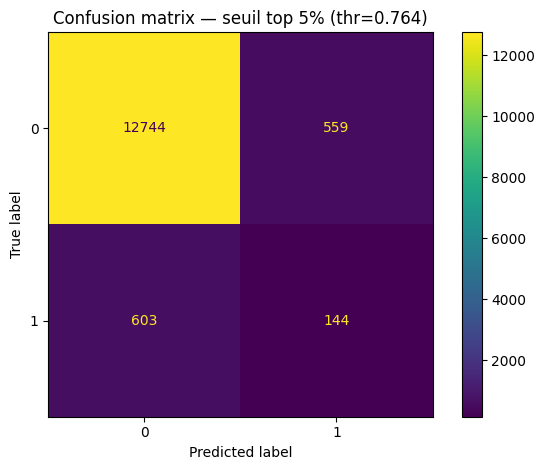

Recall (mortels captés): 0.193
Precision (dans top 5%): 0.205


In [10]:
top_percent = 0.05
threshold = float(np.quantile(proba, 1 - top_percent))
y_pred = (proba >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title(f"Confusion matrix — seuil top {int(top_percent*100)}% (thr={threshold:.3f})")
plt.tight_layout()
plt.show()

tp = cm[1,1]; fn = cm[1,0]; fp = cm[0,1]
recall = tp / (tp + fn) if (tp + fn) else 0
precision = tp / (tp + fp) if (tp + fp) else 0
print(f"Recall (mortels captés): {recall:.3f}")
print(f"Precision (dans top {int(top_percent*100)}%): {precision:.3f}")

## Analyse d’erreurs

- **Faux négatifs (FN)** : accidents mortels non détectés → risque opérationnel
- **Faux positifs (FP)** : alertes inutiles → coût en ressources

L’analyse suivante vise à identifier des patterns récurrents afin de comprendre les limites du modèle.

In [11]:
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["proba"] = proba
test_df["y_pred"] = y_pred

fn_df = test_df[(test_df["y_true"] == 1) & (test_df["y_pred"] == 0)]
fp_df = test_df[(test_df["y_true"] == 0) & (test_df["y_pred"] == 1)]

print("FN (mortels ratés):", len(fn_df))
print("FP (alertes inutiles):", len(fp_df))

display(fn_df[["hour","lum","vma","agg","dep","proba"]].head(10))
display(fp_df[["hour","lum","vma","agg","dep","proba"]].head(10))

FN (mortels ratés): 603
FP (alertes inutiles): 559


,hour,lum,vma,agg,dep,proba
25072,11,1,80,1,11,0.750898
65622,11,1,30,2,11,0.142828
24452,8,2,90,1,15,0.717587
9855,17,1,90,1,12,0.617437
34069,16,1,50,2,27,0.294803
9664,1,3,90,1,49,0.685687
52675,18,2,-1,2,42,0.711055
34914,7,1,-1,2,74,0.472757
62443,13,1,70,1,57,0.742296
37284,10,1,80,1,44,0.693784


,hour,lum,vma,agg,dep,proba
54576,6,2,80,1,18,0.771174
32256,9,1,80,1,89,0.775833
54606,17,2,110,1,988,0.855682
1068,4,3,80,1,17,0.831583
30366,23,4,80,1,53,0.806377
63987,14,1,80,1,83,0.792197
533,16,1,80,1,76,0.790420
43556,18,1,80,1,60,0.770972
36210,10,1,-1,1,34,0.789063
27260,19,3,110,1,79,0.782124


## Interprétabilité : importance des variables

La **Permutation Importance** permet d’identifier les variables ayant le plus d’impact sur la performance du modèle (PR-AUC).

Elle fournit une lecture globale des facteurs associés à un sur-risque, sans prétendre à une relation causale.

,feature,importance_mean
21,dep,0.026993
11,agg,0.016734
12,int,0.015139
20,vma,0.013591
10,situ,0.009755
5,lum,0.008766
14,circ,0.008345
13,catr,0.006850
19,larrout,0.004462
4,hrmn,0.002870


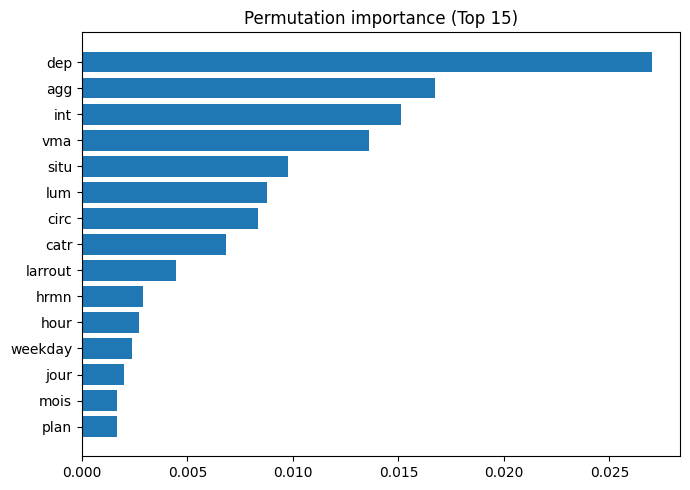

In [12]:
r = permutation_importance(
    model, X_test, y_test,
    n_repeats=5, random_state=42, scoring="average_precision"
)

imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": r.importances_mean
}).sort_values("importance_mean", ascending=False).head(15)

display(imp)

plt.figure(figsize=(7,5))
plt.barh(imp["feature"][::-1], imp["importance_mean"][::-1])
plt.title("Permutation importance (Top 15)")
plt.tight_layout()
plt.show()

## Conclusion et limites (Model Card)

- **Use case** : score de risque pour prioriser les accidents à fort potentiel de mortalité
- **Données** : BAAC 2024
- **Cible** : `is_fatal`
- **Évaluation** : PR-AUC, calibration, analyse au seuil top 5%

### Limites
- Une seule année d’apprentissage
- Absence de variables comportementales (vitesse réelle, alcool, fatigue)
- Modèle corrélationnel, non causal

### Next steps
- Entraînement multi-années avec split temporel
- Calibration avancée
- Analyses par sous-groupes (nuit/jour, type de route)